# Predicting developer salaries

The data is 5,000 answers from the Stack Overflow Developer Survey 2025. Each row is one person.
I know their country, job, years of experience, and a few other things. I also know what they earn.
My job is to guess what they earn.

**The whole project is five stages.**

1. **Look** — open the file. Find what is in it and what is broken.
2. **Fix** — remove or repair the broken parts.
3. **Shape** — turn the columns into numbers, because a model can only do maths.
4. **Learn and check** — show the model people whose pay I know. Then give it people it has never
   seen, and measure how wrong it is.
5. **Report** — how wrong, where it is worst, and what is weak about all of it.

Everything is in this one file. Nothing is hidden in another folder.

---

# Stage 1 — Look

- The survey was published exactly as people filled it in.
- Nobody removed the silly answers. Nobody filled in the blanks.
- So the first job is to find out what I actually have.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("data/survey.csv")
print("rows and columns:", raw.shape)
raw.head(3)

rows and columns: (5000, 16)


,ResponseId,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,Industry,Country,Currency,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,annual_salary_usd
0,1,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,Ukraine,EUR European Euro,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,61256.0
1,10004,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,40.0,46.0,"Developer, full-stack","10,000 or more employees",Individual contributor,"Your choice (very flexible, you can come in wh...",Computer Systems Design and Services,Germany,EUR European Euro,C#;Java;SQL,H2;MariaDB;Neo4J;Oracle,99773.0
2,10016,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,5.0,"Developer, full-stack","10,000 or more employees",Individual contributor,Remote,Healthcare,United States of America,USD United States dollar,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,Microsoft SQL Server;MongoDB,85000.0


- Next: how many people left each question blank.
- I also check the type of each column, so I know the numbers loaded as numbers and not as text.

In [81]:
pd.DataFrame({"type": raw.dtypes, "blank": raw.isna().sum()}).sort_values("blank", ascending=False)

,type,blank
DatabaseHaveWorkedWith,str,1052
ICorPM,str,602
RemoteWork,str,553
OrgSize,str,530
LanguageHaveWorkedWith,str,349
Industry,str,144
annual_salary_usd,float64,84
WorkExp,float64,52
YearsCode,float64,21
EdLevel,str,5


**What that shows.**

- `DatabaseHaveWorkedWith` is blank for 1,052 people. That is one in five.
- `ICorPM`, `RemoteWork` and `OrgSize` are each blank for about 550 people.
- That is far too many rows to throw away.
- **So whatever I build has to cope with blanks still being there.** This decides which model I pick
  later.

- Now the column I am trying to guess: `annual_salary_usd`.

In [82]:
salary = raw["annual_salary_usd"]
salary.describe(percentiles=[.01, .25, .5, .75, .99]).round(0).to_frame("annual_salary_usd")

,annual_salary_usd
count,4916.0
mean,98353.0
std,145434.0
min,1.0
1%,86.0
25%,41765.0
50%,77559.0
75%,123993.0
99%,500000.0
max,6890299.0


- The smallest is **\$1** and the biggest is **\$6,890,299**. The middle is \$77,517.
- Both ends need a decision, and they need *different* decisions. \$1 is a mistake. \$500,000 is
  believable for a senior person in the US.
- The average (\$98,353) is much higher than the middle (\$77,517). That is because a few huge
  salaries pull the average up. The middle value is the more honest summary.

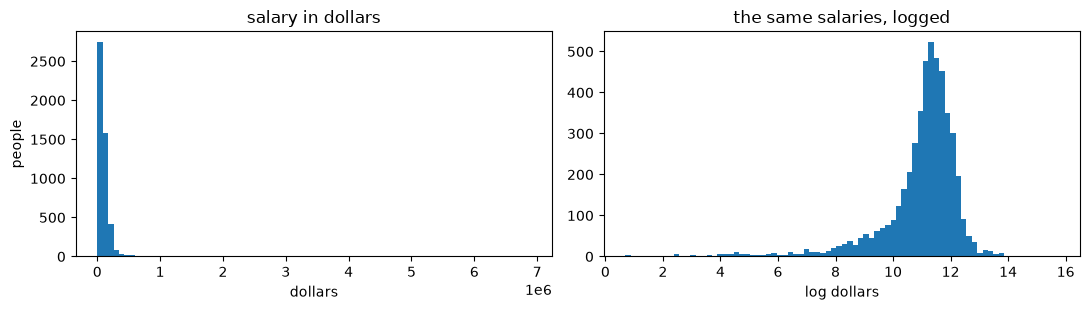

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(salary.dropna(), bins=80)
axes[0].set(title="salary in dollars", xlabel="dollars", ylabel="people")
axes[1].hist(np.log1p(salary.dropna()), bins=80)
axes[1].set(title="the same salaries, logged", xlabel="log dollars")
plt.tight_layout()

**Why the second picture matters.**

- On the left, almost everyone is squashed against the wall. A few huge salaries stretch the scale.
- A **log** squashes big numbers much more than small ones. `log(1,000)` is about 6.9 and
  `log(1,000,000)` is about 13.8, so multiplying by a thousand only adds about 7.
- On the right the shape is much more even.
- This matters because the model tries to make its **squared** mistakes small. Squaring makes big
  mistakes count far more: one \$400,000 miss counts 20 times as much as twenty \$20,000 misses.
- So without a log, the model would chase the few rich people and fit everyone else worse.
- After a log, a mistake is basically a percentage. Being 30% wrong costs the same at \$20,000 as at
  \$200,000. I use the log in stage 4, and I test whether it helped.

### The one surprise in the data

- If people typed their own salary, the most common values should be round.
- Let me check which values got reported most often.

In [84]:
top = salary.value_counts().head(6)

# `top` only has the salary values and how often each one appeared.
# To see the currency I have to go back to `raw`.
rows = raw[raw["annual_salary_usd"].isin(top.index)]
money = rows.groupby("annual_salary_usd")["Currency"].agg(
    currency=lambda c: c.mode()[0],
    all_the_same=lambda c: c.nunique() == 1,
)

pd.DataFrame({
    "how many people": top.values,
    "currency": money.loc[top.index, "currency"].values,
    "all the same currency": money.loc[top.index, "all_the_same"].values,
    "value divided by 1.16015": (top.index / 1.16015).round(1),
}, index=top.index)

,how many people,currency,all the same currency,value divided by 1.16015
annual_salary_usd,,,,
69609.0,66,EUR European Euro,True,60000.0
116015.0,60,EUR European Euro,True,100000.0
92812.0,54,EUR European Euro,True,80000.0
58007.0,53,EUR European Euro,True,49999.6
81210.0,52,EUR European Euro,True,69999.6
46406.0,47,EUR European Euro,True,40000.0


**What I found, step by step.**

- `69,609` was reported by 66 people. `116,015` by 60 people. These are not round numbers.
- 66 people would not all type the same odd number by chance. So people did not type these. Something
  made them.
- If something multiplied the numbers, the multiplier should be a real exchange rate. I looked up
  euro to dollar for 2025: it averaged about 1.13 and went as high as about 1.18.
- If `116,015` started as a round **€100,000**, then the multiplier is `116,015 / 100,000 = 1.16015`.
  That sits inside the real range.
- Other guesses do not. €200,000 would mean 0.58. €50,000 would mean 2.32. Neither is a euro rate.
- Check: at 1.16015 the other five values divide back to €80,000, €70,000, €60,000, €50,000 and
  €40,000. And the table shows all six groups were paid in euros, every single person.
- **So the salary column is a person's own pay in their own money, times one fixed rate per
  currency.**

- Last look: two columns say things that cannot be true.

In [85]:
print(raw[["WorkExp", "YearsCode"]].describe().round(1).to_string())
print()
print((raw["WorkExp"] > raw["YearsCode"]).sum(), "people worked more years than they have coded")
print((raw[["WorkExp", "YearsCode"]] > 60).sum().sum(), "answers claim more than 60 years")
print()
print(raw.groupby("Employment")["annual_salary_usd"].agg(["size", "median"]).round(0)
         .sort_values("size", ascending=False).to_string())

       WorkExp  YearsCode
count   4948.0     4979.0
mean      13.1       17.7
std        9.7       10.5
min        1.0        1.0
25%        6.0       10.0
50%       11.0       15.0
75%       18.0       25.0
max      100.0      100.0

199 people worked more years than they have coded
3 answers claim more than 60 years

                                                      size    median
Employment                                                          
Employed                                              4215   78890.0
Independent contractor, freelancer, or self-employed   589   78890.0
Not employed                                            90   73289.0
Student                                                 85   16242.0
I prefer not to say                                     11  123008.0
Retired                                                 10   72000.0


- Both `WorkExp` and `YearsCode` go up to **100 years**. Nobody has coded for 100 years.
- 199 people say they worked more years than they have written code. One of those two numbers is
  wrong and there is no way to tell which. I leave both alone and say so.
- Students earn a middle of **\$16,242**. Employed developers earn **\$78,890**. Those are two
  different groups of people, not one group with a bit of spread.

---

# Stage 2 — Fix

My rules, and why each one is there:

- **Keep only people who work.** Students are a different group (see above).
- **Drop people with no salary.** I cannot learn from them and I cannot score against them.
- **Drop salaries under \$1,000.** The column contains `1`, `3`, `6` and `22`. Those are mistakes.
  \$1,000 a year is \$83 a month, which no full-time developer earns anywhere, so this only removes
  mistakes.
- **Why \$1,000 and not something bigger?** Because of the currency finding. ₹600,000 is a normal
  Indian salary and it becomes **\$6,974**. A bigger cutoff would delete real people from poorer
  countries.
- **Cap the top half of one percent** instead of deleting them. Capping keeps that person's country,
  job and experience, and only pulls their salary down. Deleting throws all of it away.
- **Turn years over 60 into blanks.** They are impossible. I make them blank instead of guessing,
  because my model handles blanks by itself.
- **Drop one exact duplicate row.**
- **Group job titles with under 20 people into "Other".** A rule built from 3 people will not work on
  anyone new.

In [86]:
df = raw.copy()
print(f"start                          {len(df):>5} rows")

# only people who work -- students are a different group
df = df[df["Employment"].isin(["Employed",
                               "Independent contractor, freelancer, or self-employed"])]
print(f"after keeping only workers     {len(df):>5} rows")

# no salary means nothing to learn from and nothing to score against
df = df[df["annual_salary_usd"].notna()]
print(f"after dropping missing salary  {len(df):>5} rows")

# under $1,000 a year is not a real salary anywhere
df = df[df["annual_salary_usd"] >= 1_000]
print(f"after dropping under $1,000    {len(df):>5} rows")

# pull the top 0.5% down instead of deleting those people
cap = df["annual_salary_usd"].quantile(0.995)
print(f"\ncap set at ${cap:,.0f}. {(df['annual_salary_usd'] > cap).sum()} salaries pulled down to it.")
df["annual_salary_usd"] = df["annual_salary_usd"].clip(upper=cap)

# 100-year careers are impossible, so make them blank
for col in ["WorkExp", "YearsCode"]:
    df.loc[df[col] > 60, col] = np.nan

# one row is identical to another apart from its id
df = df.drop_duplicates(subset=df.columns.drop("ResponseId"))
print(f"after dropping duplicates      {len(df):>5} rows")

# rare job titles become "Other"
counts = df["DevType"].value_counts()
df["DevType"] = df["DevType"].where(df["DevType"].isin(counts[counts >= 20].index), "Other")

# the two "hybrid" answers only differ in wording, so join them
df["RemoteWork"] = df["RemoteWork"].replace({
    "Hybrid (some remote, leans heavy to in-person)": "Hybrid",
    "Hybrid (some in-person, leans heavy to flexibility)": "Hybrid",
    "Your choice (very flexible, you can come in when you want or just as needed)": "Flexible",
})

df = df.reset_index(drop=True)
print(f"\nleft with {len(df):,} rows, which is {len(df)/len(raw):.0%} of the file")

start                           5000 rows
after keeping only workers      4804 rows
after dropping missing salary   4762 rows
after dropping under $1,000     4655 rows

cap set at $696,088. 23 salaries pulled down to it.
after dropping duplicates       4654 rows

left with 4,654 rows, which is 93% of the file


---

# Stage 3 — Shape

A model can only do maths. It cannot do maths on the word "Germany". So every column has to become a
number, or be handed to a model that can read words by itself.

- **Age, education, company size** have a real order, so they become ordered numbers. Company size
  uses the middle of its range, so the gap between sizes is realistic.
- Answers like "Prefer not to say" and "I don't know" become blank. There is no correct place to put
  them in an order.
- **Manager or not** becomes 1 or 0. The 438 people who skipped it stay blank. Filling them in would
  be making up an answer for one person in eight.
- **The language list** becomes a count, plus a 1 or 0 for each of the ten most common languages. The
  count alone forgets *which* languages. One column per language would add 42 nearly-empty columns.
- **Id number and currency get dropped.** An id is different for every person, so there is no pattern
  in it. Currency is almost the same information as country.
- **Country, job, industry, remote and employment stay as words**, marked as pandas `category`. That
  marking is what lets my model split on them with no conversion at all.

In [87]:
AGE = {"18-24 years old": 1, "25-34 years old": 2, "35-44 years old": 3,
       "45-54 years old": 4, "55-64 years old": 5, "65 years or older": 6,
       "Prefer not to say": np.nan}

SCHOOL = {"Primary/elementary school": 1,
          "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2,
          "Some college/university study without earning a degree": 3,
          "Associate degree (A.A., A.S., etc.)": 4,
          "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 5,
          "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
          "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 7,
          "Other (please specify):": np.nan}

COMPANY = {"Just me - I am a freelancer, sole proprietor, etc.": 1,
           "Less than 20 employees": 10, "20 to 99 employees": 60,
           "100 to 499 employees": 300, "500 to 999 employees": 750,
           "1,000 to 4,999 employees": 3_000, "5,000 to 9,999 employees": 7_500,
           "10,000 or more employees": 15_000, "I don’t know": np.nan}

TOP_LANGUAGES = ["JavaScript", "HTML/CSS", "SQL", "Python", "TypeScript",
                 "Bash/Shell (all shells)", "C#", "Java", "C++", "Go"]

languages = df["LanguageHaveWorkedWith"].str.split(";")
databases = df["DatabaseHaveWorkedWith"].str.split(";")

X = pd.DataFrame(index=df.index)
X["WorkExp"] = df["WorkExp"].astype(float)
X["YearsCode"] = df["YearsCode"].astype(float)
X["age"] = df["Age"].map(AGE)
X["school"] = df["EdLevel"].map(SCHOOL)
X["company_size"] = df["OrgSize"].map(COMPANY)
X["is_manager"] = df["ICorPM"].map({"People manager": 1.0, "Individual contributor": 0.0})
X["how_many_languages"] = languages.str.len()
X["how_many_databases"] = databases.str.len()

for lang in TOP_LANGUAGES:
    name = "uses_" + lang.split(" ")[0].replace("/", "_")
    # exact match, so "C" does not match "C#" or "C++"
    X[name] = languages.apply(lambda l: float(lang in l) if isinstance(l, list) else np.nan)

for col in ["Country", "DevType", "RemoteWork", "Industry", "Employment"]:
    X[col] = df[col].astype("category")

y = df["annual_salary_usd"].astype(float)

print(f"X has {X.shape[0]:,} rows and {X.shape[1]} columns")

# what the model actually receives: every column's type, and the blanks still in it.
# the blanks are deliberate -- nothing is filled in, the model handles them itself.
# "blank in raw" is the same count in the untouched file, so the two can be compared.
SOURCE = {"age": "Age", "school": "EdLevel", "company_size": "OrgSize",
          "is_manager": "ICorPM", "how_many_languages": "LanguageHaveWorkedWith",
          "how_many_databases": "DatabaseHaveWorkedWith"}
source = {c: SOURCE.get(c, "LanguageHaveWorkedWith" if c.startswith("uses_") else c)
          for c in X.columns}
pd.DataFrame({"from": pd.Series(source),
              "blank in raw": pd.Series({c: raw[s].isna().sum() for c, s in source.items()}),
              "blank now": X.isna().sum(),
              "type": X.dtypes})

X has 4,654 rows and 23 columns


,from,blank in raw,blank now,type
WorkExp,WorkExp,52,30,float64
YearsCode,YearsCode,21,18,float64
age,Age,0,4,float64
school,EdLevel,5,44,float64
company_size,OrgSize,530,411,float64
is_manager,ICorPM,602,438,float64
how_many_languages,LanguageHaveWorkedWith,349,298,float64
how_many_databases,DatabaseHaveWorkedWith,1052,948,float64
uses_JavaScript,LanguageHaveWorkedWith,349,298,float64
uses_HTML_CSS,LanguageHaveWorkedWith,349,298,float64


---

# Stage 4 — Learn and check

This is the only new idea in the whole project, and it is small.

- A model that repeats back salaries it already saw is useless. I need to know how it does on **new**
  people.
- So I cut the people into **5 groups**.
- I train on 4 groups and test on the 1 left out. Then I do it again with a different group left out,
  until every group has been the test group once. That is 5 rounds.
- I average the 5 scores. Averaging is the point: one round on its own is a coin flip, five rounds
  averaged is steady.
- I do the same 5 rounds for some **deliberately dumb models** too. A score means nothing on its own.
  "Wrong by \$34,800" only becomes a result next to "and guessing the country's middle salary is
  wrong by \$41,300".

**The four things I run, worst to best:**

1. Always guess the middle salary. Ignores every column.
2. Guess the middle salary of that person's country. Uses one column.
3. The real model, trained on logged salary.
4. The same model, trained on plain dollars, so I can check whether the log actually helped.

One important detail. For the country guess I work out the middle salaries **from the training rows
only** — that is the `y_train.groupby(...)` line. If I used all the rows, each test person would have
helped make the number used to guess them, and my score would be a lie.

In [88]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

def new_model():
    return HistGradientBoostingRegressor(
        learning_rate=0.05,      # each new tree only nudges the answer
        max_iter=500,            # at most 500 trees
        max_leaf_nodes=31,       # at most 31 groups per tree
        min_samples_leaf=20,     # never build a rule from fewer than 20 people
        early_stopping=True,     # stop early once it stops improving
        n_iter_no_change=20,
        random_state=0)          # same answer every run

groups = KFold(n_splits=5, shuffle=True, random_state=0)
scores = {"1. always the middle salary": [], "2. the country's middle salary": [],
          "3. model, logged salary": [], "4. model, plain dollars": []}
guesses = pd.Series(index=y.index, dtype=float)   # one honest guess per person

for train_rows, test_rows in groups.split(X):
    X_train, X_test = X.iloc[train_rows], X.iloc[test_rows]
    y_train, y_test = y.iloc[train_rows], y.iloc[test_rows]

    # 1. always the middle salary of the training people
    g = np.full(len(y_test), y_train.median())
    scores["1. always the middle salary"].append((mean_absolute_error(y_test, g), r2_score(y_test, g)))

    # 2. that person's country's middle salary, worked out from TRAINING rows only
    middles = y_train.groupby(X_train["Country"], observed=True).median()
    g = X_test["Country"].map(middles).fillna(y_train.median())
    scores["2. the country's middle salary"].append((mean_absolute_error(y_test, g), r2_score(y_test, g)))

    # 3. the real model. train on logged salary, then undo the log on the guess
    model = new_model().fit(X_train, np.log1p(y_train))
    g = np.expm1(model.predict(X_test))
    guesses.iloc[test_rows] = g
    scores["3. model, logged salary"].append((mean_absolute_error(y_test, g), r2_score(y_test, g)))

    # 4. same model, no log, to check the log was worth it
    plain = new_model().fit(X_train, y_train)
    g = plain.predict(X_test)
    scores["4. model, plain dollars"].append((mean_absolute_error(y_test, g), r2_score(y_test, g)))

table = []
for name, rounds in scores.items():
    mae = np.array([r[0] for r in rounds])
    r2 = np.array([r[1] for r in rounds])
    table.append({"model": name, "average miss": mae.mean(),
                  "wobble between rounds": mae.std(), "R2": r2.mean()})
pd.DataFrame(table).set_index("model").round(3)

,average miss,wobble between rounds,R2
model,,,
1. always the middle salary,55247.310,562.022,-0.044
2. the country's middle salary,41300.847,833.540,0.256
"3. model, logged salary",34799.237,708.386,0.401
"4. model, plain dollars",36809.962,967.339,0.430


**How to read that.**

- **average miss** is how far off it is in dollars, averaged over everyone. My model is off by about
  \$34,800.
- **wobble between rounds** is how much that number moved across the 5 rounds. If two models differ by
  less than this, the difference is not real. Mine beats the country guess by about \$6,500 against a
  wobble of about \$700, so it is real.
- **R2** is the share of the ups and downs in salary that the model explains. 0 means no better than
  always guessing the average. 1 would be perfect.
- Row 2 is the interesting one. Knowing **only which country someone lives in** already gets most of
  the way. Most of what can be predicted about pay here is just where you live.
- Rows 3 and 4 disagree, and that is worth saying out loud. The log gives a **better average miss**
  but a **worse R2**. R2 is built on squared mistakes, so it rewards getting the very high salaries
  roughly right. The average miss treats everyone equally. I care about the ordinary person, so I keep
  the log.

---

# Stage 5 — Report

- `guesses` now holds one guess for every person, and each guess came from a round where that person
  was in the test group. So nothing here is flattered.
- First: the biggest misses.

In [89]:
miss = y - guesses
print(f"average miss ${miss.abs().mean():,.0f}")
print(f"middle miss  ${miss.abs().median():,.0f}")
print()

worst = miss.abs().sort_values(ascending=False).head(10).index
df.loc[worst, ["Country", "DevType", "WorkExp", "annual_salary_usd"]].assign(
    guessed=guesses[worst].round(0), missed_by=miss[worst].round(0))

average miss $34,799
middle miss  $19,128



,Country,DevType,WorkExp,annual_salary_usd,guessed,missed_by
3020,Ukraine,"Developer, full-stack",15.0,696088.0,14971.0,681117.0
487,India,"Developer, full-stack",3.0,696088.0,20136.0,675952.0
1740,India,"Architect, software or solutions",6.0,696088.0,36714.0,659374.0
3918,Slovenia,"Developer, back-end",6.0,696088.0,69849.0,626239.0
63,"Iran, Islamic Republic of...","Senior executive (C-suite, VP, etc.)",17.0,696088.0,81581.0,614507.0
2447,Netherlands,"Developer, back-end",17.0,696088.0,98303.0,597785.0
1859,United States of America,"Senior executive (C-suite, VP, etc.)",3.0,696088.0,98476.0,597612.0
4056,United States of America,"Developer, full-stack",5.0,696088.0,99656.0,596432.0
3238,France,"Architect, software or solutions",19.0,696088.0,100151.0,595937.0
3072,Finland,"Architect, software or solutions",20.0,696088.0,114022.0,582066.0


**The most useful thing I found, and I did not expect it.**

- The middle miss (\$19,100) is much smaller than the average miss (\$34,800). That gap means a few
  guesses are very badly wrong and they are dragging the average up.
- Every one of the ten worst guesses sits at exactly **\$696,088** — my cap from stage 2.
- Their other answers look completely ordinary. A Ukrainian full-stack developer with 15 years.
  An Indian sole trader with 3 years. Nothing in the survey says they earn most of a million.
- So the model guesses somewhere between \$15,000 and \$100,000 and is wrong by about \$600,000
  each time.
- **Capping did not fix the problem, it moved it.** It made a small group of people all sitting at one
  salary with nothing to explain why. Deleting them would make my numbers look better, but that is
  improving the score by throwing away the hard cases. I kept them and I am reporting the cost.

In [90]:
biggest = df["Country"].value_counts().head(8).index
(pd.DataFrame({"country": df["Country"], "miss": miss.abs(), "salary": y})
   .query("country in @biggest")
   .groupby("country", observed=True)
   .agg(people=("miss", "size"), average_miss=("miss", "mean"),
        middle_salary=("salary", "median"))
   .assign(miss_as_percent_of_pay=lambda t: (100 * t["average_miss"] / t["middle_salary"]).round(0))
   .sort_values("average_miss", ascending=False).round(0))

,people,average_miss,middle_salary,miss_as_percent_of_pay
country,,,,
United States of America,1027,56207.0,150000.0,37.0
United Kingdom of Great Britain and Northern Ireland,304,32352.0,94958.0,34.0
Ukraine,144,28219.0,30000.0,94.0
Canada,165,27557.0,87550.0,31.0
India,232,25253.0,20226.0,125.0
France,214,24999.0,63808.0,39.0
Germany,408,21960.0,85851.0,26.0
Italy,127,20676.0,49886.0,41.0


- In dollars the model looks worst in the US. That is not surprising: American salaries are bigger, so
  there is more to be wrong about.
- But look at the last column. As a share of local pay the order flips. The model is **worst in the
  low-paid countries**, where there are fewer people in the survey and pay varies more.
- That is a much more useful thing to say about the model than the dollar figures.

- Next: which columns is the model actually leaning on?
- The test is simple. Take a trained model. Shuffle one column so its values no longer belong to the
  right person. See how much worse the guesses get. If shuffling a column barely matters, the model
  was not using it.

In [91]:
train_rows, test_rows = next(iter(groups.split(X)))
X_train, X_test = X.iloc[train_rows], X.iloc[test_rows]
y_train, y_test = y.iloc[train_rows], y.iloc[test_rows]

model = new_model().fit(X_train, np.log1p(y_train))
before = mean_absolute_error(y_test, np.expm1(model.predict(X_test)))

damage = {}
for col in X.columns:
    muddled = X_test.copy()
    muddled[col] = muddled[col].sample(frac=1, random_state=0).values
    after = mean_absolute_error(y_test, np.expm1(model.predict(muddled)))
    damage[col] = after - before

(pd.Series(damage).sort_values(ascending=False).head(8)
   .round(0).to_frame("miss gets worse by"))

,miss gets worse by
Country,25679.0
WorkExp,2589.0
company_size,2569.0
DevType,1059.0
Industry,859.0
YearsCode,799.0
RemoteWork,588.0
uses_HTML_CSS,197.0


- **Country matters about ten times more than anything else.** Shuffling it costs around \$25,700.
  The next columns, years of work and company size, cost about \$2,600 each.
- That agrees with the country-guess model reaching an R2 of 0.256 all by itself. Two separate checks,
  same answer.
- One catch worth admitting: if two columns held the same information, shuffling either one alone
  would barely hurt, and both would look useless. That is part of why I dropped currency, which is
  nearly a copy of country.

In [92]:
pd.DataFrame({"ResponseId": df["ResponseId"], "actual": y.round(0),
              "guessed": guesses.round(0)}).to_csv("predictions.csv", index=False)
print(f"wrote predictions.csv with {len(df):,} rows")

wrote predictions.csv with 4,654 rows


---

## What is weak about this

- **The limit is the survey, not the model.** Pay depends on the exact company, the exact role, share
  options, and how well someone negotiated. None of that is in these 16 columns. An R2 near 0.40 is
  about all this data can give.
- **My cap is the single biggest cause of my error.** All ten worst guesses are capped people.
- **The cap is worked out from all the rows**, not separately in each of the 5 rounds. It touches 23
  people. Small, but it is a flaw and I would rather say it than hide it.
- **The \$1,000 cutoff is blunt.** It removes 107 rows, and 36 of those sit between \$300 and
  \$1,000, where I honestly cannot tell a very low real salary from monthly pay typed in as yearly.
- **Dropping students is a judgement call, not a fact.** Someone could reasonably keep them and let
  employment status be a column instead.
- **`WorkExp` and `YearsCode` still disagree** for 199 people. I left both in.
- **The data is self-reported.** Nobody checked these salaries, and whoever chose to answer is who I
  have. It leans towards the US and Europe.

## What I would do next

1. Move the cap and the cutoff **inside** the 5 rounds, so they cannot see the test rows at all.
2. Add an outside number for each country, like average income per person, so 130 country names
   collapse into one number and a country I have never seen still gets a sensible guess.
3. Only then try tuning the model's settings.